# Team 13

Authors: Mathis Kriwoluzky, Lennart Koch.

This notebook is our own work. Any other sources have been clearly marked and cited.

All authors contributed equally.

This notebook was run and tested in PyCharm.

---

## 1. Setup

This notebook trains a Generative Adversarial Network (GAN) to generate artistic images in the style of WikiArt. First we load the WikiArt dataset from HuggingFace, containing 1000 training samples with art images and their style classifications.

In [ ]:
import torch
from datasets import load_dataset, load_dataset_builder
from itertools import islice

# dataset name: Be careful what you get from huggingface!
ds_name="huggan/wikiart"

# get metadata
builder = load_dataset_builder(ds_name)
features = builder.info.features

# get data (subset)
N_SUB = 1000 # feel free to change (not too big, not too small)
ds_stream = load_dataset(ds_name, split="train", streaming=True)
ds = list(islice(ds_stream, N_SUB))

# the full data would be quite big and slow!
#ds = load_dataset(ds_name)

README.md:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

C:\Users\User\PycharmProjects\BildverarbeitungBeleg1\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--huggan--wikiart. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

dataset_infos.json:   0%|          | 0.00/5.91k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

## 2. Data Exploration

Load the WikiArt dataset from HuggingFace and explore its structure. This code loads 1000 training samples, analyzes the dataset features and class distribution, and plots a bar chart to check for class imbalance.

In [2]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset, load_dataset_builder
from itertools import islice
from collections import Counter

# ==========================================================
# DATA EXPLORATION
# Anforderung:
# - Dataset Ursprung, Struktur, Dimensionen untersuchen
# - Klassenverteilung analysieren
# ==========================================================

ds_name = "huggan/wikiart"

# Metadaten laden
builder = load_dataset_builder(ds_name)

print("Dataset:", ds_name)
print("Features:")
print(builder.info.features)

# Nur Teilmenge verwenden (Projektvorgabe)
N_SUB = 1000

ds_stream = load_dataset(
    ds_name,
    split="train",
    streaming=True
)

ds = list(islice(ds_stream, N_SUB))

print(f"Anzahl Samples: {len(ds)}")

# Beispiel betrachten
print(ds[0].keys())

# Klassenverteilung bestimmen
labels = [sample["style"] for sample in ds]

class_counts = Counter(labels)

print("\nKlassenverteilung:")
for cls, cnt in class_counts.items():
    print(cls, cnt)

# Kontrolle auf Klassenungleichgewicht
print("\nAnzahl Klassen:", len(class_counts))

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Dataset: huggan/wikiart
Features:
{'image': Image(mode=None, decode=True), 'artist': ClassLabel(names=['Unknown Artist', 'boris-kustodiev', 'camille-pissarro', 'childe-hassam', 'claude-monet', 'edgar-degas', 'eugene-boudin', 'gustave-dore', 'ilya-repin', 'ivan-aivazovsky', 'ivan-shishkin', 'john-singer-sargent', 'marc-chagall', 'martiros-saryan', 'nicholas-roerich', 'pablo-picasso', 'paul-cezanne', 'pierre-auguste-renoir', 'pyotr-konchalovsky', 'raphael-kirchner', 'rembrandt', 'salvador-dali', 'vincent-van-gogh', 'hieronymus-bosch', 'leonardo-da-vinci', 'albrecht-durer', 'edouard-cortes', 'sam-francis', 'juan-gris', 'lucas-cranach-the-elder', 'paul-gauguin', 'konstantin-makovsky', 'egon-schiele', 'thomas-eakins', 'gustave-moreau', 'francisco-goya', 'edvard-munch', 'henri-matisse', 'fra-angelico', 'maxime-maufra', 'jan-matejko', 'mstislav-dobuzhinsky', 'alfred-sisley', 'mary-cassatt', 'gustave-loiseau', 'fernando-botero', 'zinaida-serebriakova', 'georges-seurat', 'isaac-levitan', 'joaqu

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/huggan/wikiart/resolve/d559852d2b232e0fcf195e775866964f0564f2b5/data/train-00000-of-00072.parquet
Retrying in 1s [Retry 1/5].


Anzahl Samples: 1000
dict_keys(['image', 'artist', 'genre', 'style'])

Klassenverteilung:
21 210
4 40
20 93
12 276
23 74
3 61
17 54
24 77
15 28
9 44
7 31
10 1
2 6
0 1
25 2
18 2

Anzahl Klassen: 16


In [ ]:
import matplotlib.pyplot as plt

sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
class_labels = [x[0] for x in sorted_classes]
class_values = [x[1] for x in sorted_classes]

plt.figure(figsize=(14, 5))
plt.bar(class_labels, class_values, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Art Style")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in WikiArt Subset (N=1000)")
plt.tight_layout()
plt.show()

print("Class balance check:")
print(f"  Max samples: {max(class_values)}, Min samples: {min(class_values)}")
print(f"  Ratio max/min: {max(class_values) / min(class_values):.2f}")

## 3. Data Filtering

Remove art style classes with fewer than 100 samples and create a consistent label mapping. This ensures stable training by filtering out rare classes and mapping remaining classes to sequential indices.

In [ ]:
MIN_SAMPLES = 100

valid_classes = {
    cls for cls, cnt in class_counts.items()
    if cnt >= MIN_SAMPLES
}

filtered_ds = [
    sample for sample in ds
    if sample["style"] in valid_classes
]

print("Samples nach Filterung:", len(filtered_ds))

# Neues Mapping erstellen
class_names = sorted(list(valid_classes))

label2idx = {
    label: idx
    for idx, label in enumerate(class_names)
}

idx2label = {
    idx: label
    for label, idx in label2idx.items()
}

print(label2idx)

Samples nach Filterung: 486
{12: 0, 21: 1}


## 4. Stratified Split

Split the dataset into train (80%), validation (10%), and test (10%) sets while maintaining class distribution. Stratified sampling ensures each class is represented proportionally across all splits.

In [ ]:
from sklearn.model_selection import train_test_split

images = [sample["image"] for sample in filtered_ds]
labels = [label2idx[sample["style"]] for sample in filtered_ds]

# 80% Train
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# 10% Validation + 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print(len(X_train), len(X_val), len(X_test))

388 49 49


## 5. Image Transformation

Define image transformations for the train and validation/test sets. This includes resizing to 224x224 (required by ResNet50), data augmentation (horizontal flip, rotation) for training, tensor conversion, and ImageNet normalization.

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([

    # ResNet50 erwartet 224x224 Bilder
    transforms.Resize((224, 224)),

    # Datenaugmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    # ImageNet Normalisierung
    # notwendig da vortrainierte ResNet50 verwendet wird
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 6. Label Transformation

Create a custom WikiArtDataset class that loads images with their labels, applies transformations, and ensures RGB format. This standardizes how images and labels are processed during training and evaluation.

In [ ]:
from torch.utils.data import Dataset

class WikiArtDataset(Dataset):

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]

        # Sicherheitshalber RGB erzwingen
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]

        return image, label

## 7. Data Loaders

Create PyTorch DataLoaders for train, validation, and test datasets. The training set uses shuffling and batch size of 32, while validation and test sets are not shuffled. This enables efficient batch-wise processing during training and evaluation.

In [ ]:
from torch.utils.data import DataLoader

train_dataset = WikiArtDataset(
    X_train,
    y_train,
    train_transform
)

val_dataset = WikiArtDataset(
    X_val,
    y_val,
    val_test_transform
)

test_dataset = WikiArtDataset(
    X_test,
    y_test,
    val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Kontrolle
images_batch, labels_batch = next(iter(train_loader))

print(images_batch.shape)
print(labels_batch.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## 8. Simple CNN Model

Build a custom CNN from scratch with 2 convolutional layers (Conv → ReLU → MaxPool each), followed by an adaptive average pool and a fully connected classifier with dropout. Input and output dimensions are defined explicitly, and the total number of trainable parameters is reported.

In [ ]:
import torch
import torch.nn as nn


class SimpleCNN(nn.Module):
    """
    Simple CNN with 2 convolutional layers.
    Input:  (batch, 3, 224, 224)
    Output: (batch, num_classes)
    """

    def __init__(self, num_classes):
        super().__init__()

        # Conv Block 1: 3 -> 32 channels, 224x224 -> MaxPool -> 112x112
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Conv Block 2: 32 -> 64 channels, 112x112 -> MaxPool -> 56x56
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Adaptive pool -> fixed 7x7 feature maps regardless of input size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # Classifier: 64*7*7=3136 -> 512 -> num_classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = SimpleCNN(num_classes=num_classes)
cnn_model.to(device)

trainable_params_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Input shape:         (batch, 3, 224, 224)")
print(f"Output shape:        (batch, {num_classes})")
print(f"Trainable parameters: {trainable_params_cnn:,}")

### 8.1 Loss & Optimizer

Define CrossEntropyLoss as the loss function (appropriate for multi-class classification) and Adam as the optimizer. All parameters of the Simple CNN are trainable.

In [ ]:
import torch.nn as nn

cnn_criterion = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=1e-3
)

### 8.2 Model Training

Train the Simple CNN for 10 epochs using mini-batch gradient descent. Training and validation losses are tracked each epoch to monitor learning progress.

In [ ]:
from tqdm import tqdm

cnn_num_epochs = 10
cnn_train_losses = []
cnn_val_losses = []

for epoch in range(cnn_num_epochs):

    cnn_model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cnn_num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        cnn_optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    cnn_model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = cnn_model(images)
            loss = cnn_criterion(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{cnn_num_epochs}"
        f"  Train Loss={train_loss:.4f}"
        f"  Val Loss={val_loss:.4f}"
    )

### 8.3 Model Training – Visualization

Plot the training and validation loss curves of the Simple CNN across all epochs. This reveals whether the model converges, overfits, or underfits.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(cnn_train_losses, label="CNN Train Loss")
plt.plot(cnn_val_losses, label="CNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple CNN – Training & Validation Loss")
plt.legend()
plt.show()

### 8.4 Model Evaluation

Evaluate the trained Simple CNN on the test set. Compute the confusion matrix and per-class metrics (precision, recall, F1-score) to assess how well the CNN distinguishes between art styles.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

cnn_model.eval()
cnn_y_true = []
cnn_y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        preds = outputs.argmax(dim=1).cpu()
        cnn_y_pred.extend(preds.numpy())
        cnn_y_true.extend(labels.numpy())

cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred)
print("Confusion Matrix:")
print(cnn_cm)

print("\nClassification Report:")
print(
    classification_report(
        cnn_y_true,
        cnn_y_pred,
        target_names=class_names
    )
)

## 9. Transfer Learning

Load a pretrained ResNet50 model from ImageNet and freeze all backbone parameters. Replace the final fully connected layer with a custom classifier consisting of two linear layers with ReLU activation and dropout. Only the new classification head will be trained on the WikiArt data.

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


weights = ResNet50_Weights.IMAGENET1K_V1

model = resnet50(weights=weights)

# Vorgegebene Anforderung:
# Alle vortrainierten Parameter einfrieren
for param in model.parameters():
    param.requires_grad = False

num_classes = len(class_names)

# ==========================================================
# ERSETZEN DER LETZTEN SCHICHT
#
# Warum diese Architektur?
#
# - Linear(2048 -> 512):
#   reduziert die Merkmalsdimension
#
# - ReLU:
#   führt Nichtlinearität ein
#
# - Dropout:
#   reduziert Overfitting
#
# - Linear(512 -> num_classes):
#   finale Klassifikation
# ==========================================================

model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

# Trainierbare Parameter zählen
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainierbare Parameter:", trainable_params)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\lennart/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:09<00:00, 11.1MB/s]


Trainierbare Parameter: 1050114


### 9.1 Loss & Optimizer

Define the training loss function (CrossEntropyLoss for multi-class classification) and optimizer (Adam) with learning rate 1e-3. These will be used to update only the trainable parameters in the model's final classification head.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

### 9.2 Model Training

Train the model for 10 epochs using mini-batch gradient descent. In each epoch, the model is trained on the training set and evaluated on the validation set. Training and validation losses are tracked throughout the training process.

In [ ]:
from tqdm import tqdm

num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" Train Loss={train_loss:.4f}"
        f" Val Loss={val_loss:.4f}"
    )

100%|██████████| 13/13 [00:05<00:00,  2.50it/s]


Epoch 1/10 Train Loss=0.7898 Val Loss=0.4736


100%|██████████| 13/13 [00:04<00:00,  3.02it/s]


Epoch 2/10 Train Loss=0.5295 Val Loss=0.5037


100%|██████████| 13/13 [00:04<00:00,  2.98it/s]


...

Epoch 8/10 Train Loss=0.3977 Val Loss=0.3816


100%|██████████| 13/13 [00:04<00:00,  3.08it/s]


Epoch 9/10 Train Loss=0.3995 Val Loss=0.4711


100%|██████████| 13/13 [00:04<00:00,  3.02it/s]


Epoch 10/10 Train Loss=0.3740 Val Loss=0.4064


### 9.3 Model Training – Visualization

Visualize the training history by plotting the training and validation loss curves across all epochs. This helps assess model convergence and detect potential overfitting.

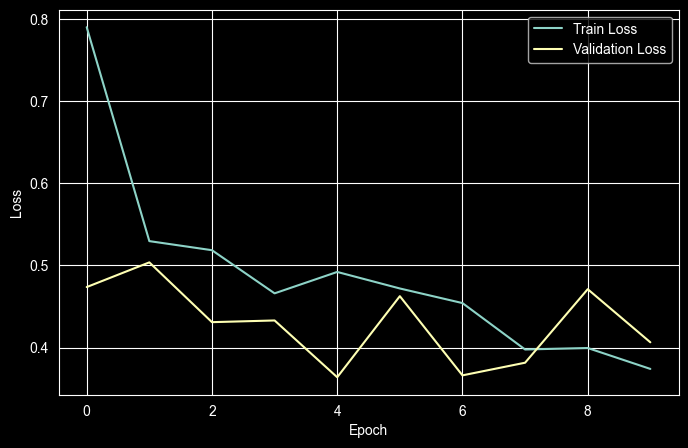

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Discussion: Observed Training Behaviour

Inspect the loss curves above and describe the observed behaviour:

- **Converging**: Both train and validation loss decrease steadily — training is working as expected.
- **Overfitting**: Train loss keeps decreasing while validation loss flattens or rises — the model memorises training data. Possible remedies: stronger Dropout, weight decay (`Adam(..., weight_decay=1e-4)`), more data augmentation, or early stopping.
- **Underfitting**: Both losses remain high — the model capacity is too low or the learning rate needs adjustment.

*Fill in your observations after running the training cell.*

### 9.4 Model Evaluation

Evaluate the trained model on the test set and compute performance metrics. Generate a confusion matrix and classification report to analyze per-class performance and identify which art styles are classified correctly or confused with each other.

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu()

        y_pred.extend(preds.numpy())
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

[[21  7]
 [ 1 20]]


TypeError: object of type 'int' has no len()

### Critique & Possible Improvements

**Critique of the Transfer Learning model:**
- The dataset is small (1000 samples total, ~800 for training), limiting generalisation.
- Class imbalance may bias predictions towards dominant art styles.
- Only the final FC layer is trained — deeper fine-tuning could yield better accuracy.
- 10 epochs may be insufficient for full convergence on a small dataset.

**Possible Improvements:**
- Increase `N_SUB` or use the full WikiArt dataset for more training data.
- Apply class-weighted loss (`nn.CrossEntropyLoss(weight=...)`) to handle class imbalance.
- Unfreeze the last few ResNet50 layers for deeper fine-tuning after the initial head training.
- Use a learning rate scheduler (e.g. `torch.optim.lr_scheduler.CosineAnnealingLR`).
- Implement early stopping to automatically stop when validation loss stops improving.

### Comparison: Simple CNN vs. Transfer Learning (ResNet50)

| Metric | Simple CNN | Transfer Learning (ResNet50) |
|---|---|---|
| Trainable parameters | — | — |
| Final Train Loss | — | — |
| Final Val Loss | — | — |
| Test Accuracy | — | — |

**Expected outcome:** Transfer Learning should significantly outperform the Simple CNN because ResNet50 leverages rich feature representations learned from 1.2M ImageNet images. The Simple CNN must learn all features from scratch with only ~800 training samples, which is a severe disadvantage.

*Fill in the table with the actual values after running both models.*